In [1]:
# Imports
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# The word2vec imports

import gensim
import gensim.downloader as api
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# The LSTM imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn import TransformerEncoder, TransformerEncoderLayer

In [37]:



    

def sentences_to_vectors(sentences, model):
    encoding_dim = model.vector_size
    no_sentence = len(sentences)
    max_word_count = 50
    
    # Initialize a 3D array with zeros
    returned_array = np.zeros((encoding_dim, max_word_count, no_sentence))

    def tokenize(sentence):
        tokens = word_tokenize(sentence)  # Tokenize sentence
        return [word for word in tokens if word not in stopwords.words('english')]  # Remove stopwords

    for i, sentence in enumerate(sentences):
        words = tokenize(sentence)
        word_vectors = [model[word] for word in words if word in model]
        
        # Pad or truncate word_vectors to fit max_word_count
        if len(word_vectors) < max_word_count:
            # Pad with zeros if there are fewer than max_word_count word vectors
            padded_vectors = np.array(word_vectors + [[0] * encoding_dim] * (max_word_count - len(word_vectors)))
        else:
            # Truncate if there are more than max_word_count word vectors
            padded_vectors = np.array(word_vectors[:max_word_count])
        
        # Fill the 3D array
        returned_array[:, :, i] = padded_vectors.T  # Transpose to match shape (encoding_dim, max_word_count)

    return returned_array


def convert_column_sentences_to_vectors(df, column_name, model):
    encoding_dim = model.vector_size
    no_sentence = len(df[column_name])
    max_word_count = 100
    
    # Initialize a 3D array with zeros
    returned_array = np.zeros((encoding_dim, max_word_count, no_sentence))

    meaningless_words = {}  

    def tokenize(sentence):
        tokens = word_tokenize(sentence)  # Tokenize sentence
        return [word for word in tokens if word.lower() not in stopwords.words('english') and word.lower() not in meaningless_words]  # Remove stopwords and meaningless words

    for i, sentence in enumerate(df[column_name]):
        words = tokenize(sentence)
        word_vectors = [model[word] for word in words if word in model]
        
        # Pad or truncate word_vectors to fit max_word_count
        if len(word_vectors) < max_word_count:
            # Pad with zeros if there are fewer than max_word_count word vectors
            padded_vectors = np.array(word_vectors + [[0] * encoding_dim] * (max_word_count - len(word_vectors)))
        else:
            # Truncate if there are more than max_word_count word vectors
            padded_vectors = np.array(word_vectors[:max_word_count])
        
        # Fill the 3D array
        returned_array[:, :, i] = padded_vectors.T  # Transpose to match shape (encoding_dim, max_word_count)

    return returned_array

In [3]:
model = api.load('glove-twitter-25')


In [48]:
import torch
import torch.nn as nn

class BiLSTMWithAttention(nn.Module):
    def __init__(self, embedding_dim, hidden_dim, output_dim):
        super(BiLSTMWithAttention, self).__init__()
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, bidirectional=True, batch_first=True)
        self.attention = nn.Linear(hidden_dim * 2, 1)  # Bidirectional -> 2 * hidden_dim
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
     lstm_out, _ = self.lstm(x)  # Shape: (batch_size, seq_len, hidden_dim * 2)

     # Calculate attention scores
     attn_weights = torch.softmax(self.attention(lstm_out), dim=1)  # Shape: (batch_size, seq_len, 1)
    
     # Calculate the context vector as a weighted sum of the LSTM outputs
     context_vector = torch.sum(attn_weights * lstm_out, dim=1)  # Shape: (batch_size, hidden_dim * 2)

     # Fully connected layer for classification
     logit = self.fc(context_vector)

     # Apply softmax to the output to get probabilities
     output = torch.sigmoid(logit)
     
    
     return output,logit,attn_weights.squeeze(-1)  # Return the attention weights


# Initialize the model
modelLSTM = BiLSTMWithAttention(embedding_dim=model.vector_size, hidden_dim=128, output_dim=1)  # Adjust parameters as needed



In [38]:
# Here we load the ready data.

data_dir = r"C:\Users\timur\Documents\GitHub\EmailSentin\data\ready_data.csv"
df_processed_data = pd.read_csv(data_dir)

mapping = {
    'Very Informal': -2,
    'Informal': -1,
    'Neutral': 0,
    'Formal': 1,
    'Very Formal': 2
}


# Encoding the sentences and extracting ground truth array. 

encoded_matrix = convert_column_sentences_to_vectors(df_processed_data, 'text', model)
# Convert the label column to a NumPy array
df_processed_data['numerical_label'] = df_processed_data['label'].map(mapping)
ground_truth = df_processed_data['numerical_label']

# The train test split.

encoded_matrix_transposed = np.transpose(encoded_matrix, (2, 0, 1))  # Rearrange to shape (1333, 25, 25)

# Perform a train-test split
X_train, X_test, y_train, y_test = train_test_split(
    encoded_matrix_transposed, 
    ground_truth, 
    test_size=0.2,  # 20% for testing
    random_state=41,  # For reproducibility
    shuffle=True  # Shuffle the samples before splitting
)

y_train = np.array(y_train)
y_train = np.nan_to_num(y_train, nan=0.0)  # Replace NaNs with 0.0
y_train_binary = y_train[y_train != 0]  # Remove 0s
y_train_binary = np.where(y_train_binary > -1, 1, 0)  # 1 if y_train > 0, otherwise 0
y_train_binary = torch.tensor(y_train_binary, dtype=torch.float32)    # Corresponding targets for regression

y_test = np.array(y_test)
y_test_binary = y_test[y_test != 0]  # Remove 0s
y_test_binary = np.where(y_test_binary > 0, 1, 0)  # 1 if y_train > 0, otherwise 0
y_test_binary = torch.tensor(y_test_binary, dtype=torch.float32)    # Corresponding targets for regression

X_train = X_train[y_train != 0] 
X_train = torch.tensor(X_train, dtype=torch.float32).transpose(-1, -2)  # Input data (1066 sequences)
X_test = X_test[y_test != 0] 
X_test = torch.tensor(X_test, dtype=torch.float32).transpose(-1, -2)   






In [50]:


# Set parameters
input_size = 25    # Number of features
hidden_size = 50   # Number of hidden units in LSTM
num_layers = 1     # Number of LSTM layer
batch_size = 1    # Batch size
num_epochs = 50  # Number of epochs
learning_rate = 0.000013  # Learning rate




# Initialize the model, loss function, and optimizer

criterion = nn.BCELoss()  
optimizer = optim.Adam(modelLSTM.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    total_loss = 0  # Variable to accumulate the loss for the epoch
    num_batches = 0  # Counter for the number of batches

    for i in range(0, X_train.size(0), batch_size):
        # Get the current batch
        batch_data = X_train[i:i + batch_size] 
        batch_targets = y_train_binary[i:i + batch_size]  # Shape: (batch_size, 1)

        # Reshape the batch targets to match the shape of outputs
        batch_targets = batch_targets.unsqueeze(1)  # Add extra dimension to make it (batch_size, 1)

        # Forward pass
        outputs,logits,attn= modelLSTM(batch_data)
        
       
        

        # Calculate loss
        loss = criterion(outputs, batch_targets)
        
        # Accumulate the loss for the current batch
        total_loss += loss.item()
        num_batches += 1

        # Backward pass and optimization
        optimizer.zero_grad()  # Zero gradients
        loss.backward()        # Backpropagation
        optimizer.step()       # Update weights

    # Calculate the average loss for the epoch
    average_loss = total_loss / num_batches
    
    # Print the average loss for the epoch
    print(f'Epoch [{epoch + 1}/{num_epochs}], Average Loss: {average_loss:.4f}')

Epoch [1/50], Average Loss: 0.6891
Epoch [2/50], Average Loss: 0.6800
Epoch [3/50], Average Loss: 0.6643
Epoch [4/50], Average Loss: 0.5928
Epoch [5/50], Average Loss: 0.4490
Epoch [6/50], Average Loss: 0.4070
Epoch [7/50], Average Loss: 0.3903
Epoch [8/50], Average Loss: 0.3805
Epoch [9/50], Average Loss: 0.3762
Epoch [10/50], Average Loss: 0.3730
Epoch [11/50], Average Loss: 0.3626
Epoch [12/50], Average Loss: 0.3609
Epoch [13/50], Average Loss: 0.3590
Epoch [14/50], Average Loss: 0.3566
Epoch [15/50], Average Loss: 0.3517
Epoch [16/50], Average Loss: 0.3516
Epoch [17/50], Average Loss: 0.3477
Epoch [18/50], Average Loss: 0.3531
Epoch [19/50], Average Loss: 0.3422
Epoch [20/50], Average Loss: 0.3417
Epoch [21/50], Average Loss: 0.3435
Epoch [22/50], Average Loss: 0.3336
Epoch [23/50], Average Loss: 0.3383
Epoch [24/50], Average Loss: 0.3340
Epoch [25/50], Average Loss: 0.3322
Epoch [26/50], Average Loss: 0.3296
Epoch [27/50], Average Loss: 0.3276
Epoch [28/50], Average Loss: 0.3248
E

In [52]:
torch.save(modelLSTM.state_dict(), "model_2_atn.pth")

Accuracy on the test set: 87.74%


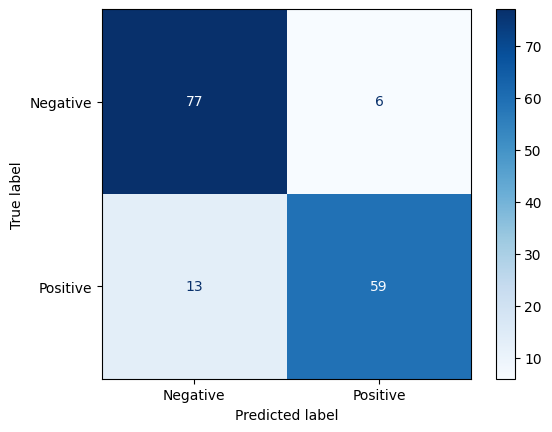

In [46]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

modelLSTM.eval()  # Set the model to evaluation mode

# Initialize variables to keep track of correct predictions and true labels
correct = 0
total = 0
all_preds = []
all_targets = []

# No need to calculate gradients during testing
with torch.no_grad():
    for i in range(0, X_test.size(0), batch_size):
        # Get the current test batch
        batch_data = X_test[i:i + batch_size]
        batch_targets = y_test_binary[i:i + batch_size]

        # Reshape the batch targets to match the shape of outputs
        batch_targets = batch_targets.unsqueeze(1)  # Make it (batch_size, 1)

        # Forward pass to get predictions
        outputs,_ = modelLSTM(batch_data)


        # Apply sigmoid to get probabilities, and convert to binary predictions (0 or 1)
        
        predicted = (outputs > 0.5).float()  # Threshold at 0.41 for binary classification
        

        # Store predictions and true labels for confusion matrix
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(batch_targets.cpu().numpy())

        # Update the count of correct predictions
        total += batch_targets.size(0)  # Total number of samples in this batch
        correct += (predicted == batch_targets).sum().item()  # Count correct predictions

# Calculate accuracy
accuracy = correct / total * 100  # Convert to percentage
print(f'Accuracy on the test set: {accuracy:.2f}%')

# Generate confusion matrix
cm = confusion_matrix(all_targets, all_preds)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])  # Modify as per your labels
disp.plot(cmap=plt.cm.Blues)
plt.show()


In [47]:
from sklearn.model_selection import KFold
import numpy as np

# Set parameters
input_size = 25    # Number of features
hidden_size = 50   # Number of hidden units in LSTM
num_layers = 1     # Number of LSTM layer
batch_size = 1    # Batch size
num_epochs = 100  # Number of epochs
learning_rate = 0.00001  # Learning rate


X = encoded_matrix_transposed 
y = np.array(ground_truth)
y = np.nan_to_num(y, nan=0.0)  # Replace NaNs with 0.0
X = X[y != 0]
X = torch.tensor(X, dtype=torch.float32)   


y = y[y != 0]  # Remove 0s
y_bin = np.where(y > -1, 1, 0)  # 1 if y_train > 0, otherwise 0
y_bin = torch.tensor(y_bin , dtype=torch.float32)    # Corresponding targets for regression

# Parameters for k-fold cross-validation
k_folds = 5  # You can adjust this based on the dataset size

# Initialize KFold
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# Initialize variables to track accuracy across folds
fold_accuracies = []

# Iterate over each fold
for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    print(f"Fold {fold + 1}/{k_folds}")
    
    # Split the data into train and validation sets for this fold
    X_fold_train, X_fold_test = X[train_idx], X[test_idx]
    y_fold_train, y_fold_test = y_bin[train_idx], y_bin[test_idx]
    
    # Convert the data to tensors for PyTorch
    X_fold_train = torch.tensor(X_fold_train, dtype=torch.float32).transpose(-1, -2)
    X_fold_test = torch.tensor(X_fold_test, dtype=torch.float32).transpose(-1, -2)
    y_fold_train = torch.tensor(y_fold_train, dtype=torch.float32)
    y_fold_test = torch.tensor(y_fold_test, dtype=torch.float32)
    
    # Initialize the model for this fold
    modelLSTM = BiLSTMWithAttention(input_size, hidden_size, num_layers)
    criterion = nn.BCELoss()  
    optimizer = optim.Adam(modelLSTM.parameters(), lr=learning_rate)

    # Train the model for this fold
    for epoch in range(num_epochs):
        modelLSTM.train()  # Set model to training mode
        total_loss = 0
        num_batches = 0
        
        for i in range(0, X_fold_train.size(0), batch_size):
            batch_data = X_fold_train[i:i + batch_size]
            batch_targets = y_fold_train[i:i + batch_size]
            batch_targets = batch_targets.unsqueeze(1)

            # Forward pass
            outputs = modelLSTM(batch_data)
            loss = criterion(outputs, batch_targets)
            
            total_loss += loss.item()
            num_batches += 1

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        average_loss = total_loss / num_batches
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {average_loss:.4f}')
    
    # Evaluation on the fold's validation set
    modelLSTM.eval()  # Set model to evaluation mode
    
    correct = 0
    total = 0
    
    with torch.no_grad():
        for i in range(0, X_fold_test.size(0), batch_size):
            batch_data = X_fold_test[i:i + batch_size]
            batch_targets = y_fold_test[i:i + batch_size]
            batch_targets = batch_targets.unsqueeze(1)
            
            outputs = modelLSTM(batch_data)
            predicted = (outputs > 0.5).float()
            
            total += batch_targets.size(0)
            correct += (predicted == batch_targets).sum().item()

    # Calculate fold accuracy
    fold_accuracy = correct / total * 100
    fold_accuracies.append(fold_accuracy)
    print(f'Accuracy for fold {fold + 1}: {fold_accuracy:.2f}%')

# Calculate and print average accuracy across all folds
average_accuracy = np.mean(fold_accuracies)
print(f'\nAverage Accuracy across {k_folds} folds: {average_accuracy:.2f}%')


Fold 1/5


C:\Users\timur\AppData\Local\Temp\ipykernel_58260\126462878.py:42: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_fold_train = torch.tensor(X_fold_train, dtype=torch.float32).transpose(-1, -2)
C:\Users\timur\AppData\Local\Temp\ipykernel_58260\126462878.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_fold_test = torch.tensor(X_fold_test, dtype=torch.float32).transpose(-1, -2)
C:\Users\timur\AppData\Local\Temp\ipykernel_58260\126462878.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_fold_train = torch.tensor(y_fold_train, dty

AttributeError: 'tuple' object has no attribute 'size'

In [17]:
# Now trying with chatgpt generated data (for now composed only of singular sentences)

data_dir = r"C:\Users\timur\Documents\GitHub\EmailSentin\data\gpt_generated\formality_detection_test_set_expanded.csv"
df_processed_data = pd.read_csv(data_dir)

mapping = {
    'Very Informal': -2,
    'Informal': -1,
    'Neutral': 0,
    'Formal': 1,
    'Very Formal': 2
}


# Encoding the sentences and extracting ground truth array. 

encoded_matrix = convert_column_sentences_to_vectors(df_processed_data, 'text', model)
# Convert the label column to a NumPy array
df_processed_data['numerical_label'] = df_processed_data['label'].map(mapping)
ground_truth = df_processed_data['numerical_label']

# The train test split.

encoded_matrix_transposed = np.transpose(encoded_matrix, (2, 0, 1))  # Rearrange to shape (1333, 25, 25)
X = encoded_matrix_transposed 
y = np.array(ground_truth)
y = np.nan_to_num(y, nan=0.0)  # Replace NaNs with 0.0
X = X[y != 0]
X = torch.tensor(X, dtype=torch.float32).transpose(-1, -2)   


y = y[y != 0]  # Remove 0s
y_bin = np.where(y > -1, 1, 0)  # 1 if y_train > 0, otherwise 0
y_bin = torch.tensor(y_bin , dtype=torch.float32)    # Corresponding targets for regression



In [18]:
X[3]

tensor([[ 0.8471, -1.0349, -0.0504,  ..., -1.1732,  0.5820,  0.3385],
        [-0.0758,  0.6615,  0.7864,  ..., -0.5430, -0.5441, -1.8118],
        [-0.4647,  0.9694, -0.1987,  ..., -0.3299,  0.2819, -0.8740],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]])

Accuracy on the test set: 100.00%


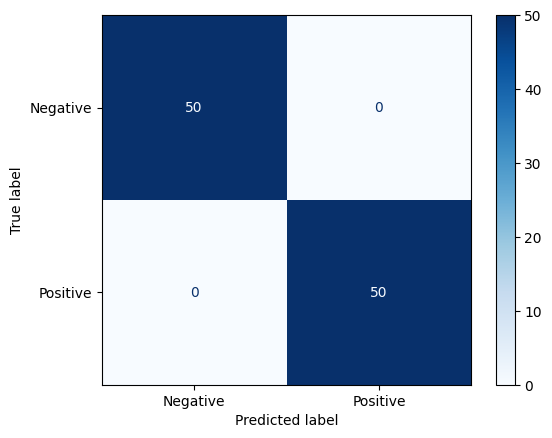

In [19]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

modelLSTM.eval()  # Set the model to evaluation mode

# Initialize variables to keep track of correct predictions and true labels
correct = 0
total = 0
all_preds = []
all_targets = []

# No need to calculate gradients during testing
with torch.no_grad():
    for i in range(0, X.size(0), batch_size):
        # Get the current test batch
        batch_data = X[i:i + batch_size]
        batch_targets = y_bin[i:i + batch_size]

        # Reshape the batch targets to match the shape of outputs
        batch_targets = batch_targets.unsqueeze(1)  # Make it (batch_size, 1)

        # Forward pass to get predictions
        outputs = modelLSTM(batch_data)

        # Apply sigmoid to get probabilities, and convert to binary predictions
        predicted = (outputs > 0.5).float()  # Threshold at 0.41 for binary classification

        # Store predictions and true labels for confusion matrix
        all_preds.extend(predicted.cpu().numpy().astype(int))
        all_targets.extend(batch_targets.cpu().numpy().astype(int))

        # Update the count of correct predictions
        total += batch_targets.size(0)  # Total number of samples in this batch
        correct += (predicted == batch_targets).sum().item()  # Count correct predictions

# Calculate accuracy
accuracy = correct / total * 100  # Convert to percentage
print(f'Accuracy on the test set: {accuracy:.2f}%')

# Generate confusion matrix
cm = confusion_matrix(all_targets, all_preds)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])  # Modify as per your labels
disp.plot(cmap=plt.cm.Blues)
plt.show()


In [23]:
import torch
import numpy as np
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Assuming 'model' is your word embedding model loaded previously
# Example: model = gensim.models.KeyedVectors.load("path/to/your/model")

# Function to preprocess text and convert it into a tensor of word vectors
def preprocess_text(text, model, max_word_count=100):
    encoding_dim = model.vector_size
    # Tokenize and filter out stopwords
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    meaningful_words = [word for word in tokens if word.lower() not in stop_words]

    # Get word vectors
    word_vectors = [model[word] for word in meaningful_words if word in model.key_to_index]

    # Pad or truncate to max_word_count
    if len(word_vectors) < max_word_count:
        padded_vectors = np.array(word_vectors + [[0] * encoding_dim] * (max_word_count - len(word_vectors)))
    else:
        padded_vectors = np.array(word_vectors[:max_word_count])

    # Convert to tensor with the correct type and add a batch dimension
    return torch.tensor(padded_vectors, dtype=torch.float32).unsqueeze(0)  # Shape: (1, max_word_count, encoding_dim)

# Function to classify user input
def classify_text(input_text, model):
    # Preprocess the input text
    processed_text = preprocess_text(input_text, model)

    # Set the model to evaluation mode
    modelLSTM.eval()
    
    with torch.no_grad():
        # Forward pass to get predictions
        outputs = modelLSTM(processed_text)
        print(outputs)

        # Apply sigmoid to get probabilities, and convert to binary predictions
        predicted = (outputs > 0.5).float()  # Threshold for binary classification

        # Convert prediction to numpy for easier handling
        prediction = predicted.cpu().numpy().astype(int)

        # Interpret prediction
        if prediction[0] == 1:
            return "Formal",
        else:
            return "Informal"

# Main loop for user input
while True:
    user_input = input("Enter text for classification (type 'exit' to quit): ")
    if user_input.lower() == 'exit':
        break
    result = classify_text(user_input, model)  # Pass the model as an argument
    print(f'The classification result is: {result}')


tensor([[0.1810]])
The classification result is: Informal
tensor([[0.1810]])
The classification result is: Informal
tensor([[0.1810]])
The classification result is: Informal
